In [2]:
import os, time, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)

BASE = "/content/drive/MyDrive/diploma"
DATA = f"{BASE}/data/processed"
EMB  = f"{BASE}/data/embeddings"
MODELS = f"{BASE}/models/hybrid"
RESULTS = f"{BASE}/results"
FIGURES = f"{BASE}/figures"
os.makedirs(MODELS, exist_ok=True)

RANDOM_STATE = 42

Mounted at /content/drive


In [4]:
df = pd.read_parquet(f"{DATA}/dataset_split.parquet")
train = df[df.split == "train"].reset_index(drop=True)
val   = df[df.split == "val"].reset_index(drop=True)
test  = df[df.split == "test"].reset_index(drop=True)

y_train, y_val, y_test = train.label.values, val.label.values, test.label.values

# FastText
ft_train = np.load(f"{EMB}/fasttext_train.npy")
ft_val   = np.load(f"{EMB}/fasttext_val.npy")
ft_test  = np.load(f"{EMB}/fasttext_test.npy")

# BERT-CLS (берём CLS, т.к. он чуть лучше отработал в этапе 6)
bert_train = np.load(f"{EMB}/bert_cls_train.npy")
bert_val   = np.load(f"{EMB}/bert_cls_val.npy")
bert_test  = np.load(f"{EMB}/bert_cls_test.npy")

print(f"FastText: {ft_train.shape}, BERT-CLS: {bert_train.shape}")

FastText: (210000, 300), BERT-CLS: (210000, 312)


In [5]:
t0 = time.perf_counter()

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_tfidf_train = tfidf.fit_transform(train.text)
X_tfidf_val   = tfidf.transform(val.text)
X_tfidf_test  = tfidf.transform(test.text)

svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
tfidf_train = svd.fit_transform(X_tfidf_train)
tfidf_val   = svd.transform(X_tfidf_val)
tfidf_test  = svd.transform(X_tfidf_test)

print(f"TF-IDF→SVD: {tfidf_train.shape}, "
      f"объяснённая дисперсия: {svd.explained_variance_ratio_.sum():.3f}, "
      f"время: {time.perf_counter()-t0:.1f} сек")

TF-IDF→SVD: (210000, 300), объяснённая дисперсия: 0.297, время: 84.0 сек


In [6]:
X_train = np.hstack([tfidf_train, ft_train, bert_train]).astype(np.float32)
X_val   = np.hstack([tfidf_val,   ft_val,   bert_val  ]).astype(np.float32)
X_test  = np.hstack([tfidf_test,  ft_test,  bert_test ]).astype(np.float32)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Гибрид: {X_train.shape}")  # ожидаем (N, 912)

Гибрид: (210000, 912)


In [7]:
def evaluate(clf, name):
    res = {"approach": "hybrid", "classifier": name}
    for split_name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        y_pred = clf.predict(X)
        if hasattr(clf, "predict_proba"):
            y_score = clf.predict_proba(X)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_score = clf.decision_function(X)
        else:
            y_score = y_pred
        res[f"{split_name}_accuracy"]  = accuracy_score(y, y_pred)
        res[f"{split_name}_precision"] = precision_score(y, y_pred, average="macro", zero_division=0)
        res[f"{split_name}_recall"]    = recall_score(y, y_pred, average="macro", zero_division=0)
        res[f"{split_name}_f1_macro"]  = f1_score(y, y_pred, average="macro", zero_division=0)
        res[f"{split_name}_roc_auc"]   = roc_auc_score(y, y_score)
    t0 = time.perf_counter()
    clf.predict(X_test)
    res["inference_ms_per_sample"] = (time.perf_counter()-t0)/len(y_test)*1000
    return res

In [8]:
results = []

# LogReg
print("LogReg...")
t0 = time.perf_counter()
lr = LogisticRegression(max_iter=1000, class_weight="balanced",
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
print(f"  обучен за {time.perf_counter()-t0:.1f} сек")
r = evaluate(lr, "LogisticRegression"); r["train_time_sec"] = time.perf_counter()-t0
results.append(r)
joblib.dump(lr, f"{MODELS}/hybrid_logreg.pkl")

# LinearSVC + калибровка для proba
print("LinearSVC...")
t0 = time.perf_counter()
svc = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000),
    cv=3
)
svc.fit(X_train, y_train)
print(f"  обучен за {time.perf_counter()-t0:.1f} сек")
r = evaluate(svc, "LinearSVC"); r["train_time_sec"] = time.perf_counter()-t0
results.append(r)
joblib.dump(svc, f"{MODELS}/hybrid_svm.pkl")

# RandomForest (умеренные параметры — иначе долго на 912 dim)
print("RandomForest...")
t0 = time.perf_counter()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=25, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
print(f"  обучен за {time.perf_counter()-t0:.1f} сек")
r = evaluate(rf, "RandomForest"); r["train_time_sec"] = time.perf_counter()-t0
results.append(r)
joblib.dump(rf, f"{MODELS}/hybrid_rf.pkl")

df_res = pd.DataFrame(results)
df_res.to_csv(f"{RESULTS}/hybrid_metrics.csv", index=False)
df_res[["classifier","test_f1_macro","test_roc_auc","test_accuracy","train_time_sec"]]

LogReg...
  обучен за 36.8 сек
LinearSVC...
  обучен за 125.3 сек
RandomForest...
  обучен за 1448.3 сек


,classifier,test_f1_macro,test_roc_auc,test_accuracy,train_time_sec
0,LogisticRegression,0.946616,0.996936,0.983044,37.679243
1,LinearSVC,0.972683,0.997001,0.992022,128.508309
2,RandomForest,0.942800,0.992706,0.984222,1454.126895


In [9]:
train_texts = set(train.text)
test_texts  = set(test.text)
val_texts   = set(val.text)

overlap_train_test = len(train_texts & test_texts)
overlap_train_val  = len(train_texts & val_texts)

print(f"Train ∩ Test: {overlap_train_test} ({overlap_train_test/len(test)*100:.2f}%)")
print(f"Train ∩ Val:  {overlap_train_val} ({overlap_train_val/len(val)*100:.2f}%)")
print(f"Уникальных текстов в train: {len(train_texts)}/{len(train)}")

Train ∩ Test: 0 (0.00%)
Train ∩ Val:  0 (0.00%)
Уникальных текстов в train: 210000/210000


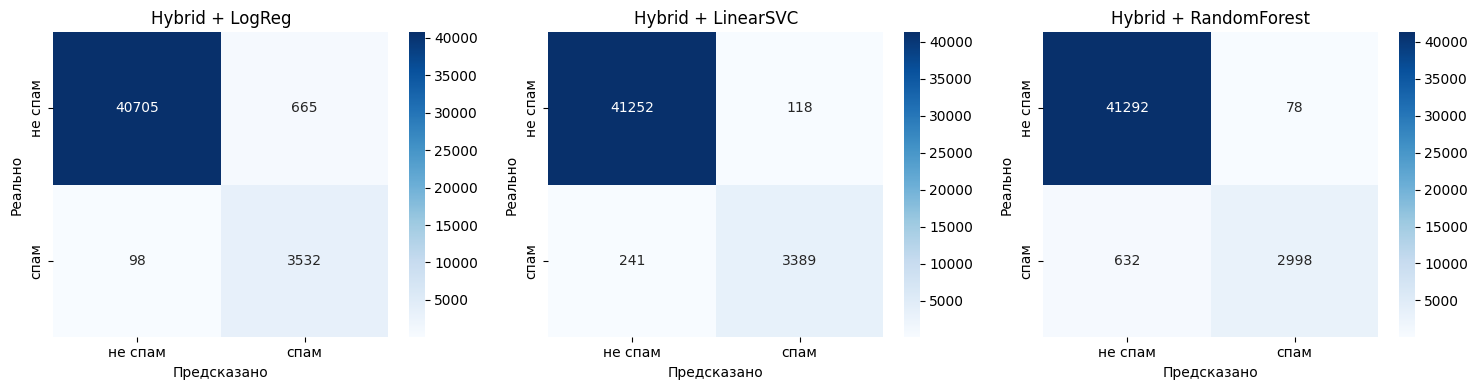

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (clf, name) in zip(axes, [(lr,"LogReg"),(svc,"LinearSVC"),(rf,"RandomForest")]):
    cm = confusion_matrix(y_test, clf.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["не спам","спам"], yticklabels=["не спам","спам"])
    ax.set_title(f"Hybrid + {name}")
    ax.set_xlabel("Предсказано"); ax.set_ylabel("Реально")
plt.tight_layout()
plt.savefig(f"{FIGURES}/hybrid_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()